# Fundamental strategy: key performance indicators

**Author:** Jan  
**Last updated:** 2026-05-20

Reports weekly (Friday-close) metrics of the production fundamental vertical against an equal-weight benchmark over the training window (2008 to 2024) and the validation window (2025). Test data (2026) is untouched.

## TL;DR

This notebook now computes KPIs from the exact production signal path (`get_weights(as_of_date)`), removing drift between reported performance and live submissions.

Run all cells to refresh the KPI table below. Key changes versus earlier versions:
- Point-in-time signal path is used throughout.
- Sortino uses standard downside deviation.
- Ratio metrics are suppressed for windows shorter than 52 weeks to avoid unstable estimates.

## 0. Strategy in plain English

**Universe:** 4 ETFs (ACWI, AGG, GLD, BSV). Baseline = 25% each.

**Signal:** monthly change in the 10-year real yield (FRED `DFII10`), smoothed (3-month) and z-scored over a 24-month window. Falling real yields make gold relatively more attractive, so the model tilts toward GLD via `MAX_TILT * tanh(-z)` (capped at +/- 15pp from baseline) when the smoothed change is negative.

**Output:** weights for ACWI, AGG, GLD, BSV that sum to 1, with GLD in [10%, 40%] and the other three sharing the remainder equally.

The strategy is purely rates-driven; macro regime classification is handled by Rayane's vertical separately and does not enter this signal.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import TRAIN_END, VAL_END
from src.data import load_etf_prices
from src.fundamental import BASELINE_WEIGHT, MAX_TILT, UNIVERSE, get_weights
from src.metrics import compute_kpis, portfolio_returns

pd.options.display.float_format = "{:.4f}".format
np.random.seed(0)

PERIODS_PER_YEAR = 52
MIN_PERIODS_FOR_RATIO_METRICS = 52

## 2. Data

Weekly Friday-close ETF returns for competition-consistent evaluation. The backtest window runs from 2008-01-04 through validation end.

In [2]:
prices = load_etf_prices(UNIVERSE, start="2008-01-01")
full_dates = pd.date_range("2008-01-04", VAL_END, freq="W-FRI")
weekly_returns = prices.resample("W-FRI").last().pct_change().reindex(full_dates)

print(f"ETF returns: {weekly_returns.index.min().date()} to {weekly_returns.index.max().date()} ({len(weekly_returns)} weeks)")

ETF returns: 2008-01-04 to 2025-12-26 (939 weeks)


## 3. Build strategy and benchmark return series

In [3]:
weights = pd.DataFrame([get_weights(date) for date in full_dates], index=full_dates)
strat = portfolio_returns(weights, weekly_returns)
bench = portfolio_returns(pd.DataFrame(0.25, index=full_dates, columns=UNIVERSE), weekly_returns)

print(f"Strategy return series:   {len(strat)} weekly observations")
print(f"Benchmark return series:  {len(bench)} weekly observations")
print(f"GLD weight range: {weights['GLD'].min():.2%} to {weights['GLD'].max():.2%} (baseline 25%)")

Strategy return series:   926 weekly observations
Benchmark return series:  926 weekly observations
GLD weight range: 10.04% to 39.89% (baseline 25%)


## 4. KPI computation

Weekly returns are annualised with factor 52 (volatility and ratio metrics use $\sqrt{52}$). KPI logic is imported from `src.metrics.compute_kpis` so this notebook matches the production reporting path. Sortino uses standard downside deviation across all periods (MAR = 0, rf = 0). Ratio metrics are suppressed when the sample is shorter than 52 weeks.

In [4]:
windows = {
    "train (through 2024-12-31)": (None, TRAIN_END),
    "validation (2025)": (TRAIN_END, VAL_END),
    "full sample": (None, VAL_END),
}

records = []
for label, (lo, hi) in windows.items():
    mask = pd.Series(True, index=strat.index)
    if lo is not None:
        mask &= strat.index > lo
    if hi is not None:
        mask &= strat.index <= hi
    s = strat[mask]
    b = bench.reindex(s.index)
    records.append({
        "window": label,
        "strategy": "Fundamental",
        **compute_kpis(
            s,
            b,
            periods_per_year=PERIODS_PER_YEAR,
            min_periods_for_ratio_metrics=MIN_PERIODS_FOR_RATIO_METRICS,
        ),
    })
    records.append({
        "window": label,
        "strategy": "Equal-weight",
        **compute_kpis(
            b,
            periods_per_year=PERIODS_PER_YEAR,
            min_periods_for_ratio_metrics=MIN_PERIODS_FOR_RATIO_METRICS,
        ),
    })

kpi_df = pd.DataFrame(records).set_index(["window", "strategy"])
kpi_df = kpi_df.rename(
    columns={
        "n_periods": "n_weeks",
        "arithmetic_ann_return": "ann_return",
        "Sharpe_rf0": "Sharpe",
        "Sortino_rf0": "Sortino",
        "best_period": "best_week",
        "worst_period": "worst_week",
        "active_sharpe_vs_bench": "info_ratio_vs_bench",
    }
)

## 5. Results

### 5.1 KPI table

In [5]:
pretty_names = {
    "n_weeks":             "N weeks",
    "total_return":        "Total return",
    "CAGR":                "CAGR",
    "ann_return":          "Ann. return",
    "ann_vol":             "Ann. vol",
    "Sharpe":              "Sharpe",
    "Sortino":             "Sortino",
    "max_drawdown":        "Max DD",
    "calmar":              "Calmar",
    "hit_rate":            "Hit rate",
    "best_week":           "Best week",
    "worst_week":          "Worst week",
    "info_ratio_vs_bench": "IR vs EW",
    "excess_ann_return":   "Excess return",
}
pct_cols = {"Total return", "CAGR", "Ann. return", "Ann. vol", "Max DD",
            "Hit rate", "Best week", "Worst week", "Excess return"}
ratio_cols = {"Sharpe", "Sortino", "Calmar", "IR vs EW"}

fmt = kpi_df.rename(columns=pretty_names).copy()
for c in fmt.columns:
    if c in pct_cols:
        fmt[c] = fmt[c].map(lambda x: f"{x:.2%}" if pd.notna(x) else "")
    elif c in ratio_cols:
        fmt[c] = fmt[c].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")
if "N weeks" in fmt:
    fmt["N weeks"] = fmt["N weeks"].astype(int)
fmt

N weeks Total return    CAGR  \
window                     strategy                                     
train (through 2024-12-31) Fundamental       874      127.98%   5.03%   
                           Equal-weight      874      126.43%   4.98%   
validation (2025)          Fundamental        52       26.68%  26.68%   
                           Equal-weight       52       25.30%  25.30%   
full sample                Fundamental       926      188.81%   6.14%   
                           Equal-weight      926      183.72%   6.03%   

                                        Ann. return Ann. vol Sharpe Sortino  \
window                     strategy                                           
train (through 2024-12-31) Fundamental        5.21%    7.77%  0.671   0.974   
                           Equal-weight       5.15%    7.49%  0.687   1.002   
validation (2025)          Fundamental       23.88%    6.05%  3.950   9.023   
                           Equal-weight      22.74%    5.40%  4.209   9.087   
full sample                Fundamental        6.26%    7.70%  0.812   1.196   
                           Equal-weight       6.13%    7.41%  0.828   1.221   

                                          Max DD  Calmar Hit rate Best week  \
window                     strategy                                           
train (through 2024-12-31) Fundamental   -19.98%   0.252   54.92%     7.13%   
                           Equal-weight  -19.19%   0.260   55.38%     6.79%   
validation (2025)          Fundamental    -2.12%  12.559   71.15%     2.73%   
                           Equal-weight   -2.17%  11.681   75.00%     2.09%   
full sample                Fundamental   -19.98%   0.307   55.83%     7.13%   
                           Equal-weight  -19.19%   0.314   56.48%     6.79%   

                                        Worst week IR vs EW Excess return  
window                     strategy                                        
train (through 2024-12-31) Fundamental      -9.11%    0.037         0.06%  
                           Equal-weight     -7.51%                         
validation (2025)          Fundamental      -2.12%    0.773         1.14%  
                           Equal-weight     -2.17%                         
full sample                Fundamental      -9.11%    0.073         0.12%  
                           Equal-weight     -7.51%

Notes:
- Ratio metrics are hidden for short windows (`<52` weeks) to avoid unstable Sharpe/Sortino/IR estimates.
- *IR vs EW* is the active-return Sharpe (annualised mean / std of strategy minus benchmark).
- *Sharpe* and *Sortino* are reported with `rf = 0` for consistency with prior project reporting.

### 5.2 Equity curves

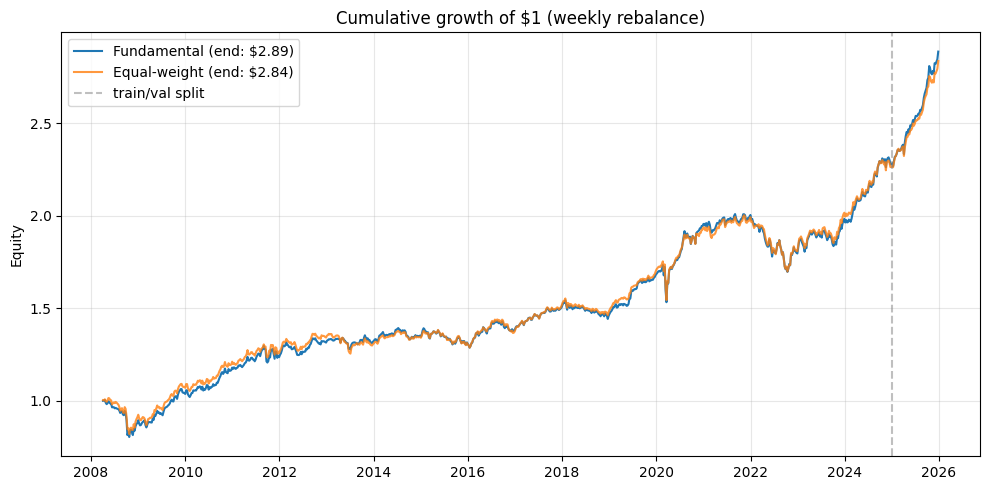

In [6]:
eq_s = (1 + strat).cumprod()
eq_b = (1 + bench).cumprod()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(eq_s.index, eq_s.values, label=f"Fundamental (end: ${eq_s.iloc[-1]:.2f})", linewidth=1.5)
ax.plot(eq_b.index, eq_b.values, label=f"Equal-weight (end: ${eq_b.iloc[-1]:.2f})", linewidth=1.5, alpha=0.8)
ax.axvline(TRAIN_END, color="grey", linestyle="--", alpha=0.5, label="train/val split")
ax.set_title("Cumulative growth of $1 (weekly rebalance)")
ax.set_ylabel("Equity")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()

### 5.3 Drawdowns

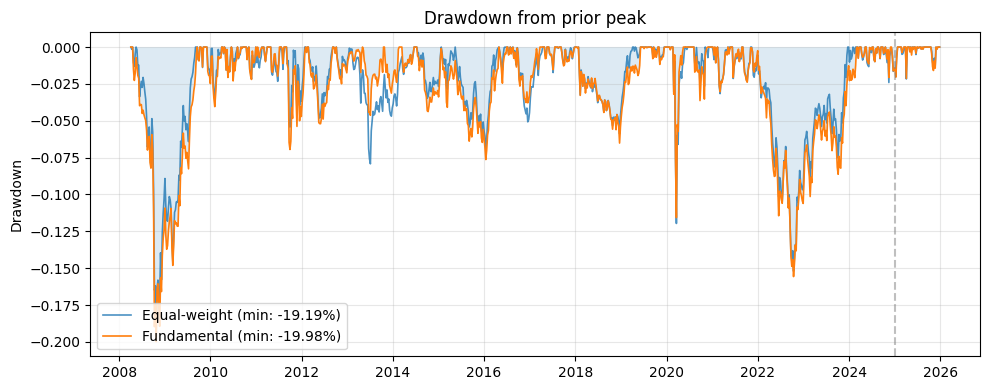

In [7]:
dd_s = eq_s / eq_s.cummax() - 1
dd_b = eq_b / eq_b.cummax() - 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dd_b.index, dd_b.values, label=f"Equal-weight (min: {dd_b.min():.2%})", linewidth=1.2, alpha=0.8)
ax.plot(dd_s.index, dd_s.values, label=f"Fundamental (min: {dd_s.min():.2%})", linewidth=1.2)
ax.fill_between(dd_s.index, dd_s.values, 0, alpha=0.15)
ax.axvline(TRAIN_END, color="grey", linestyle="--", alpha=0.5)
ax.set_title("Drawdown from prior peak")
ax.set_ylabel("Drawdown")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()

### 5.4 Rolling 52-week Sharpe

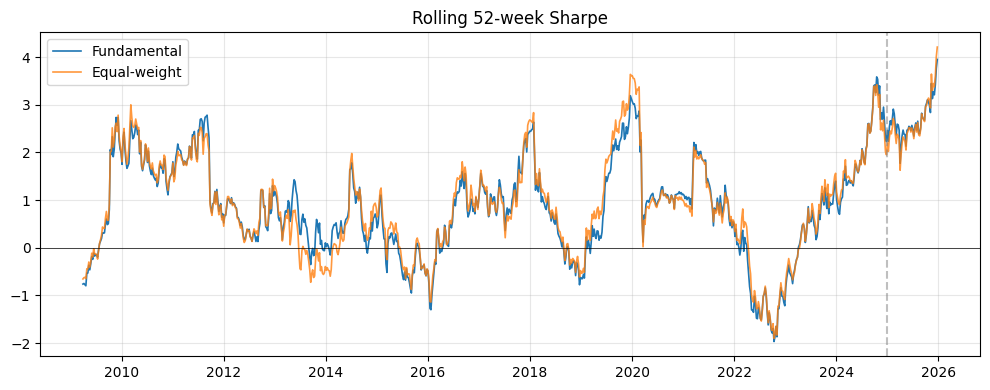

In [8]:
def rolling_sharpe(ret: pd.Series, window: int = 52) -> pd.Series:
    return (ret.rolling(window).mean() / ret.rolling(window).std()) * np.sqrt(PERIODS_PER_YEAR)

rs_s = rolling_sharpe(strat)
rs_b = rolling_sharpe(bench)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rs_s.index, rs_s.values, label="Fundamental", linewidth=1.2)
ax.plot(rs_b.index, rs_b.values, label="Equal-weight", linewidth=1.2, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(TRAIN_END, color="grey", linestyle="--", alpha=0.5)
ax.set_title("Rolling 52-week Sharpe")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

### 5.5 GLD weight over time

The model's only degree of freedom. Above 25% = bullish gold (real yields falling); below 25% = bearish gold. Capped at +/- 15pp from the 25% baseline.

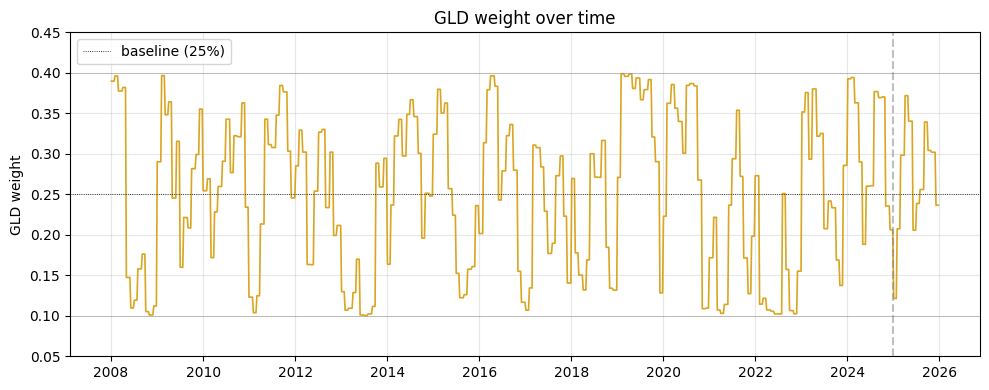

In [9]:
gld_w = weights["GLD"].reindex(full_dates, method="ffill").dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gld_w.index, gld_w.values, linewidth=1.2, color="goldenrod")
ax.axhline(BASELINE_WEIGHT, color="black", linewidth=0.6, linestyle=":", label="baseline (25%)")
ax.axhline(BASELINE_WEIGHT + MAX_TILT, color="grey", linewidth=0.5, alpha=0.6)
ax.axhline(BASELINE_WEIGHT - MAX_TILT, color="grey", linewidth=0.5, alpha=0.6)
ax.axvline(TRAIN_END, color="grey", linestyle="--", alpha=0.5)
ax.set_title("GLD weight over time")
ax.set_ylabel("GLD weight")
ax.set_ylim(0.05, 0.45)
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()

### 5.6 Calendar-year returns

Compounded weekly returns within each calendar year. Lets you see year-by-year performance rather than just the windowed averages above.

,Fundamental,Equal-weight,Excess
Year,,,
2008,-12.13%,-9.08%,-3.04%
2009,18.48%,18.10%,0.38%
2010,13.19%,12.72%,0.47%
2011,4.78%,3.77%,1.01%
2012,6.38%,6.77%,-0.39%
2013,0.40%,-2.64%,3.04%
2014,2.46%,3.08%,-0.62%
2015,-2.72%,-2.51%,-0.21%
2016,5.18%,4.76%,0.42%


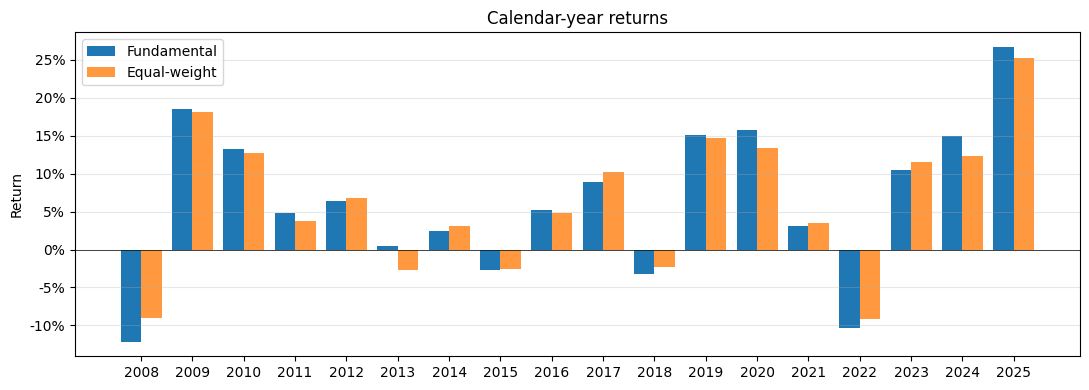

In [10]:
def yearly_returns(ret: pd.Series) -> pd.Series:
    return ret.groupby(ret.index.year).apply(lambda r: (1 + r).prod() - 1)

cy = pd.DataFrame({
    "Fundamental": yearly_returns(strat),
    "Equal-weight": yearly_returns(bench),
})
cy["Excess"] = cy["Fundamental"] - cy["Equal-weight"]
cy.index.name = "Year"

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(cy))
width = 0.4
ax.bar(x - width/2, cy["Fundamental"], width, label="Fundamental")
ax.bar(x + width/2, cy["Equal-weight"], width, label="Equal-weight", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(cy.index, rotation=0)
ax.set_title("Calendar-year returns")
ax.set_ylabel("Return")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()

cy_fmt = cy.copy()
for c in cy_fmt.columns:
    cy_fmt[c] = cy_fmt[c].map(lambda x: f"{x:.2%}")
cy_fmt

## 6. Notes / next steps

- **Tilt size is intentionally small** (`MAX_TILT=0.15` around a 25% GLD baseline). The strategy tracks equal-weight closely; the edge shows up in total return premium and downside metrics (Sortino, MaxDD, worst-week), not in raw Sharpe.
- **Validation = ~52 weeks** (full calendar 2025). Weekly validation Sharpe and IR are still noisy, but materially more informative than a 12-point monthly window.
- **No discretionary overrides**: every weight here is produced by `src.fundamental.get_weights`. The submission path enforces the 25pp weekly turnover cap against the latest prior submission.
- **Next step for the team blend:** rerun this notebook with the four-vertical combined signal as the benchmark (instead of equal-weight) once Sacha / Rayane / Cesar's outputs and the blending weights `w_J, w_S, w_R, w_C` are wired up in `src/`.